# Funkcje do wczytania

In [20]:
from xai_func import run_analysis_pipeline
from prepare_data import extract_mel_spectrogram
from ASV_dl_func import *

## Odświeżenie modułów

In [21]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Wczytanie danych
## Wybór cechy i ekstrakcja
Etap obejmuje wczytanie ścieżek do nagrań z labelami, ekstrakcję cech (spektrogramów), usunięcie brakujących wartości oraz zbalansowanie klas w celu uzyskania rzetelnego zbioru do ewaluacji.

In [16]:
feature_extractors_map = {"mel-spect": extract_mel_spectrogram}

## Przetwarzanie danych

In [17]:
X_test = pd.read_csv("csvki/test_data.csv")
X_test = extract_features(X_test, feature_extractors_map)
X_test = X_test.dropna()
X_test_bez_scalowania = balance_func(X_test, col_name='label')

   - Ekstrahuję: mel-spect


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   24.3s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   27.3s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:   33.6s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:   42.4s
[Parallel(n_jobs=-1)]: Done 1380 tasks      | elapsed:   55.3s


Zbilansowane dane: true=1033, false=1033


[Parallel(n_jobs=-1)]: Done 2000 out of 2000 | elapsed:  1.1min finished


### Uruchomienie Potoku XAI

Wybór konkretnej próbki ze zbioru testowego (zdefiniowanej przez `idx`) i uruchomienie pełnej analizy.
Kod wykonuje następujące kroki:
1. **Wczytuje obiekty** (skaler, wagi modelu).
2. **Dokonuje predykcji** (klasyfikacja Real/Spoof wraz z pewnością).
3. **Oblicza XAI** (Grad-CAM++ oraz Occlusion Sensitivity).
4. **Generuje raport słowny i graficzna reprezentacja**.

In [ ]:
idx = 1690
sample_data = X_test_bez_scalowania.iloc[idx]


>>> Analiza próbki (Prawdziwa Etykieta: 1) | Rozmiar: (64, 63)

 MODEL: best_model_1.pt
Wynik modelu: Klasa 1 (Pewność: 82.1%)

Grad-CAM++ (Ogólna)
Analiza słowna predykcji modelu


Kiedy model analizuje?
   Decyzja zapadła głównie przez analizę sekcji: 'Końcówka nagrania'.
   Stanowi to 44.1% całej uwagi modelu.

Na jakiej wysokości dźwięku skupia się model?
   Model umiarkowanie skupił się na pasmie: Średnie tony (Mowa).
   Co daje Model skupił się na brzmieniu głosu i wymawianych słowach. znaczenie dla modelu
   To pasmo ma następującą siłę wpływu: 46.1%.

Occlusion Sensitivity (Test przez zasłanianie)
Analiza słowna predykcji modelu


Kiedy model analizuje?
   Decyzja zapadła głównie przez analizę sekcji: 'Początek nagrania'.
   Stanowi to 38.7% całej uwagi modelu.

Na jakiej wysokości dźwięku skupia się model?
   Model umiarkowanie skupił się na pasmie: Wysokie tony (Szum/Detale).
   Co daje Model szukał cyfrowych artefaktów, szumów lub 'syczenia' typowego dla manipulacji głosowy

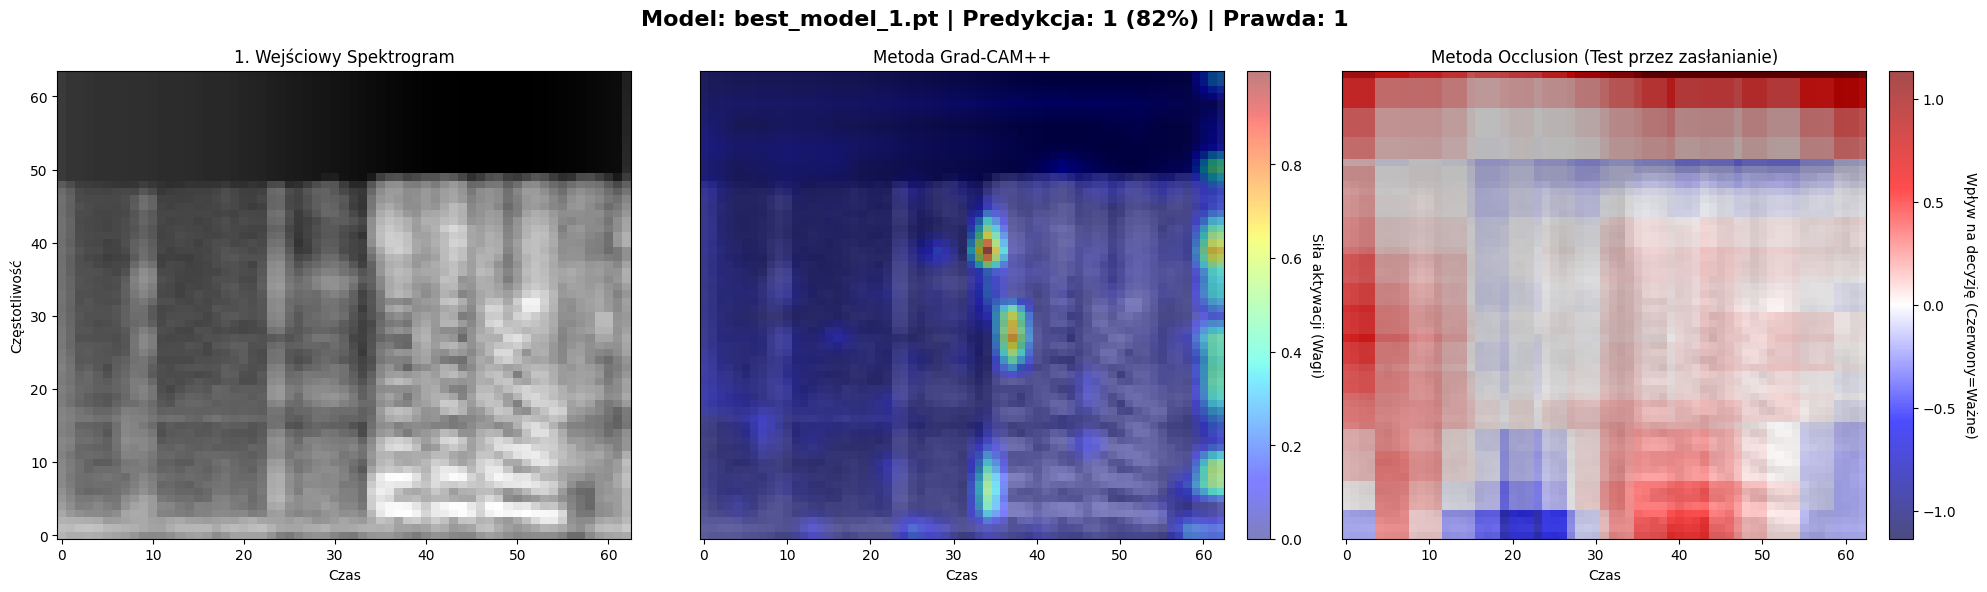


 MODEL: best_model_2.pt
Wynik modelu: Klasa 1 (Pewność: 88.3%)

Grad-CAM++ (Ogólna)
Analiza słowna predykcji modelu


Kiedy model analizuje?
   Decyzja zapadła głównie przez analizę sekcji: 'Początek nagrania'.
   Stanowi to 57.6% całej uwagi modelu.

Na jakiej wysokości dźwięku skupia się model?
   Model umiarkowanie skupił się na pasmie: Średnie tony (Mowa).
   Co daje Model skupił się na brzmieniu głosu i wymawianych słowach. znaczenie dla modelu
   To pasmo ma następującą siłę wpływu: 43.0%.

Occlusion Sensitivity (Test przez zasłanianie)
Analiza słowna predykcji modelu


Kiedy model analizuje?
   Decyzja zapadła głównie przez analizę sekcji: 'Początek nagrania'.
   Stanowi to 55.6% całej uwagi modelu.

Na jakiej wysokości dźwięku skupia się model?
   Model bardzo silnie skupił się na pasmie: Niskie tony (Bas/Tło).
   Co daje Model nasłuchiwał tła, buczenia mikrofonu lub głębi głosu. znaczenie dla modelu
   To pasmo ma następującą siłę wpływu: 66.7%.


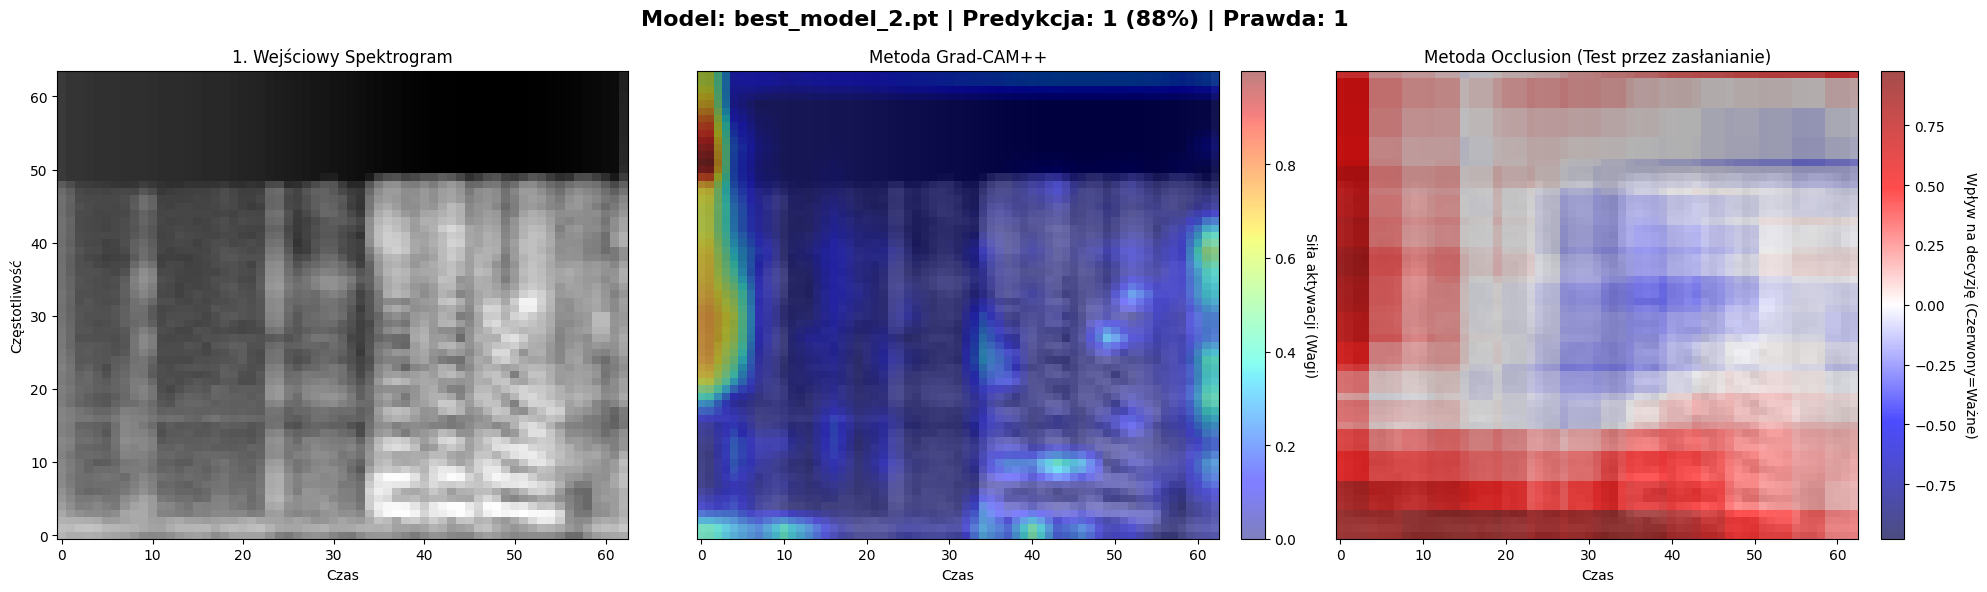

In [23]:
model_folder="best_model/"
run_analysis_pipeline(
            data_row=sample_data,
            model_folder=model_folder,
            model_class=AntiSpoofingResNet)